### Proof of concept for derivations of CHMM in a Variational inference framework

##### Simple markov chain in order to test the predictive capacity of the derivations I've found for a PC free energy frame work. 
Since idk anything else that euler's method I'll use that. I could also implement something to do with a learning rate etc btu tbd with Fabian. \
Other option could be to copy the markov chain in the original CHMM paper as a POC for the PC method

Couple comments on notation : 
- Time is in T and tau 
- Transition matrix will thus be in A, and parametrization in a 
- Hidden state values are in Q, parametrization in h

### I think something is fundamentally wrong with the way latent states are used. Softmax won't work if you want 2 clones to have importance. I probably need to reset the latent states once they've been used once right ? But in that case then they aren't a measure of successful learning. Only the T matrix is ...

## Current 

Nothing works but I also think that it isnt really made to work as it is written right now. latent states with softmax doesn't make sense does it ? you should be updating on all the connections...

Updated the equation for parameter learning to remove the 2

In [63]:
## Libs 
import numpy as np
import pandas as pd
import numpy.random as rd
import scipy as sc
from tqdm import tqdm as tqdm
import seaborn as sns

4
5
6
7
8
9
10
11


<Axes: >

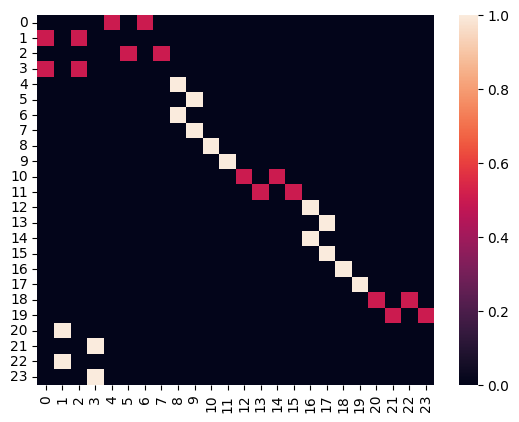

In [64]:
############################## Model matrix


######## Initialize parameters of the environment --- to include in CHMM class eventually when I make this more generalizable

#Initialize clone number vector
obs = np.arange(0,14,step=1)
n_clones = 2 #Temp TO REMOVE 
n_clones = (np.ones(shape=obs.shape, dtype=np.int64))
n_clones[4:] = n_clones[4:]*2 #Attribute 2 clones to the noisy observations


# Create the latent state labels, clones are next to each other 
latent_labels = []
for z in range(len(obs)):
    for clone in range(n_clones[z]):
        latent_labels.append(z)
latent_labels = np.array(latent_labels)
# Create label matrix 
T_labels = [] ## Shouldn't be necessary in the end        
        
# Example parse to find the appropriate clones
state_loc = np.hstack((np.array([0], dtype=n_clones.dtype), n_clones)).cumsum() # Inds of the first clone of each ensemble
clone_slice = slice(state_loc[5],state_loc[5]+n_clones[5]) 
test1 = latent_labels[clone_slice] #example


def decoder(x,n_clones=n_clones,location_start=state_loc): # give slice coordinates in general coords for the clones mapped to emission x
    #will need extra work for more complex stimulus space than intergers
    clone_slice = slice(location_start[x],location_start[x]+n_clones[x])
    return clone_slice



#####33
k = 4 # Number of noise steps 
dim = latent_labels.shape[0]


A = np.zeros(shape=(dim,dim))

# Signal nodes, manual picking
# 0 nodes
A[4,0] = 0.5
A[6,0] = 0.5

A[0,1] = 0.5
A[2,1] = 0.5

A[5,2] = 0.5
A[7,2] = 0.5

A[0,3] = 0.5
A[2,3] = 0.5 


# Noise nodes, sequentially pick MANUAL FOR THE END
progress = 0
for x in range(4,len(n_clones)-2): # need to advance on each step ? or jsut go on n clones and do it in 3 steps is etter
    print(x)
    progress += 1
    if progress%4 == 1 : 
        start = decoder(x) 
        arrival = decoder(x+2)
        A[arrival,start] = np.diag(np.full(2,1))
    elif progress%4 == 2:
        start = decoder(x) 
        arrival = decoder(x+1)
        A[arrival,start] = np.diag(np.full(2,1))
    elif progress%4 == 3:
        start = decoder(x) 
        arrival = decoder(x+1)
        A[arrival,start] = np.diag(np.full(2,1))
    elif progress%4 == 0:
        start = decoder(x) 
        arrival_1 = decoder(x+1)
        arrival_2 = decoder(x+2)
        A[arrival_1,start] = np.diag(np.full(2,0.5))
        A[arrival_2,start] = np.diag(np.full(2,0.5))

# Tail end
x = 12
start = decoder(x) 
A[1,start] = np.array([1,0])
A[3,start] = np.array([0,1])

x = 13
start = decoder(x) 
A[1,start] = np.array([1,0])
A[3,start] = np.array([0,1])

sns.heatmap(A.T)



In [65]:
latent_labels[6]

np.int64(5)

100%|██████████| 1100/1100 [00:00<00:00, 73510.42it/s]


np.int64(9)

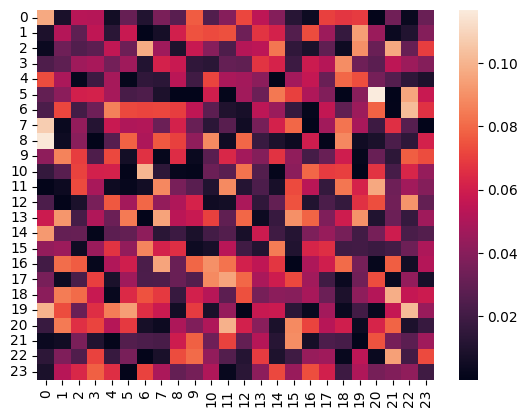

In [66]:
## CHMM Toy model Dedieu et al 2019 - Matrix 
    
    
## Gradients for Inference and learning

''' 
Gradients for softmax prior and softmax transition matrix within clones. 
Gradients on the parametrization
/ ! \ : This example introduces cases where you have 1 node wiring to 2
'''

    # Grad clone/latent state
def error(Qnow,Qprev,Transition, eps=1e-10): #w/ smoothing for impossible transitions
    # return -np.log(Qnow) + np.log(np.linalg.matmul(Transition,Qprev)[np.newaxis].T + eps) + np.ones(shape=Qnow.shape)*2 #vector column 
    return -np.log(Qnow) + np.log(np.linalg.matmul(Transition,Qprev) + eps) #vector column 

def dh(Qnow,Qprev,Transition): # Free energy derivation for hidden states (E step)
    
    e = error(Qnow,Qprev,Transition)
    avg_e = np.ones(shape=e.shape)*np.linalg.matmul(Qnow.T,e) #vector for the average in the shape of e. Global inhibitory effect
    return np.clip(Qnow*(e-avg_e), -10, 10) #Clip gradient value for prior parametrization after smoothing in order to handle log pass of impossible events

    # Grad clones t-1 --> clones t transition matrix

a_grad_clip = 1

def da(Qnow,Qprev,Transition,eps=1e-10): #Free energy derivation for transition probabilities (M step)
    Num = (Qprev*Transition)
    Denom = np.linalg.matmul(Transition,Qprev) + eps # eps is form of smoothing
    return Qnow[np.newaxis].T*(np.clip(Num/(Denom[np.newaxis].T),-a_grad_clip,a_grad_clip)-Transition) 
''' Num = product of Qprev elements * rows of Transition. Denom = First do matrix product of T.Qprev, then make sure that each row of Num is divided by the same element of Denom - hence .T that makes it a column and does this  '''




########## Innitialization

'''
ONGOING shift the initialization to an appropriate labelling matrix that can be used instead of pandas

from paper : 

state_loc = np.hstack((np.array([0], dtype=n_clones.dtype), n_clones)).cumsum() #cum sum ensures that you jump from clone to clone. to have all the clones you use this jump and then you sum the corresponding amount of clones | Clever, no need for labels

n_clones = (
    np.ones(OBS, dtype=np.int64) * 5
)  # Number of clones specifies the capacity for each observation.
'''



## Innitialize latent states NB : currently i do this before every inference loop 
# Initialize latent states - rand
h_params = rd.rand(latent_labels.shape[0])
h = np.zeros(shape=latent_labels.shape)#soft max in slices
for clone in range(len(n_clones)):
    clone_slice = slice(state_loc[clone],state_loc[clone]+n_clones[clone])
    h[clone_slice] = sc.special.softmax(h_params[clone_slice]) 




''' These 2 methodologies pretty much result in the same thing. Might be worth a try initializing without softmax and just renormalizing but should also look the same or close, just swinging around uniform distributions '''

# Initialize transition matrix cA - softmax : too homogenous
a = rd.rand(np.sum(n_clones),np.sum(n_clones))
cA = np.zeros(shape=(np.sum(n_clones),np.sum(n_clones)))

cA = sc.special.softmax(a,axis=1)

# Try to engineer softmax from uniform - not sure super smart - but once I have a really sparse thing maybe
cA = rd.rand(np.sum(n_clones),np.sum(n_clones))
cA /= np.sum(cA,axis=0)

C = 1 #arbitrary constant
a = np.log(cA) + C


# Same for power law 
''' This is more promising '''
power = 0.8 #power law exponent, lower gives more sparsity as lower value events are more likely
cA = rd.power(power,size=(np.sum(n_clones),np.sum(n_clones)))
cA /= np.sum(cA,axis=0)

C = 1 #arbitrary constant
a = np.log(cA) + C

# sns.heatmap(cA,vmin=0,vmax=1)
sns.heatmap(cA)

'''
Generate sequence - 
'''

## Decoder - encoder

def decoder(x,n_clones=n_clones,location_start=state_loc): # give slice coordinates in general coords for the clones mapped to emission x
    #will need extra work for more complex stimulus space than intergers
    clone_slice = slice(state_loc[x],state_loc[x]+n_clones[x])
    return clone_slice


'''
Encoder decoder (here not very useful)
'''

def encoder(x,latent_labels=latent_labels): # converts poisitons to observation
        return latent_labels[x]

def encoder_old(x,k=k):
    if x in np.arange(0,4+(3*k-2)):
        return x
    else :
        return x - (3*k-2)

####################
## Training sequence
####################

# training sequence creation
position = 0
POS = np.arange(A.shape[0]) 
T = 1100 # sequence length

seq = [np.int64(0)]

for t in tqdm(range(T)):
    position = rd.choice(a = POS, p = A[:,position]) #Update position according to transition matrix
    seq.append(encoder(position)) #Append decoded sequence
    
position


#### Inference and learning loop

Implementing pandas option 

  9%|▉         | 98/1099 [00:06<01:07, 14.78it/s]

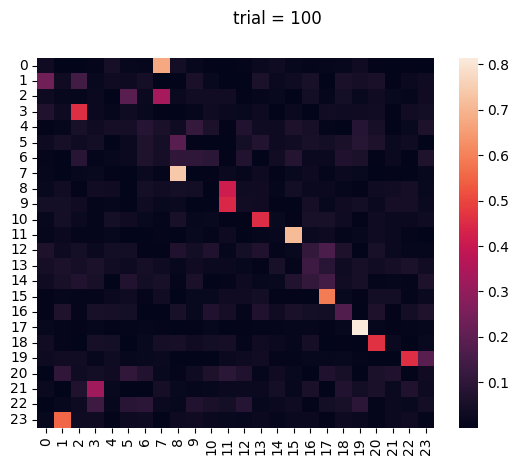

 18%|█▊        | 198/1099 [00:13<01:02, 14.43it/s]

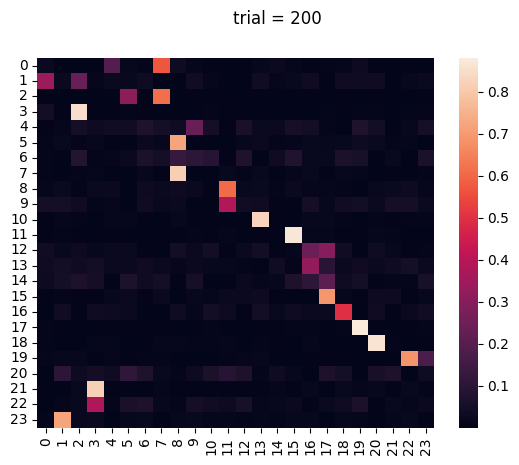

 27%|██▋       | 298/1099 [00:20<00:53, 14.99it/s]

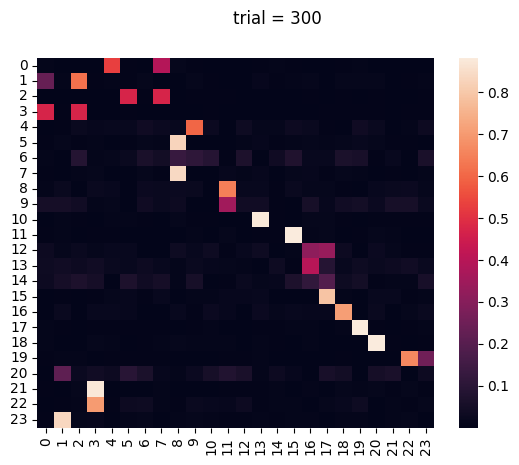

 36%|███▌      | 398/1099 [00:27<00:49, 14.21it/s]

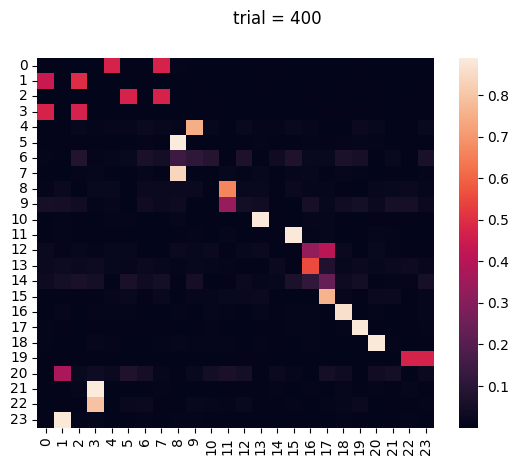

 45%|████▌     | 498/1099 [00:34<00:40, 14.79it/s]

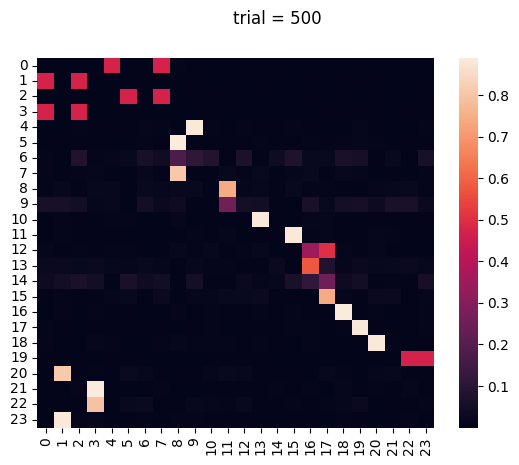

 54%|█████▍    | 598/1099 [00:41<00:33, 15.04it/s]

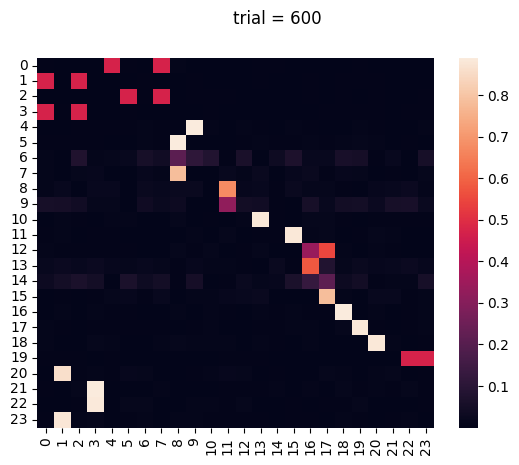

 64%|██████▎   | 698/1099 [00:48<00:29, 13.79it/s]

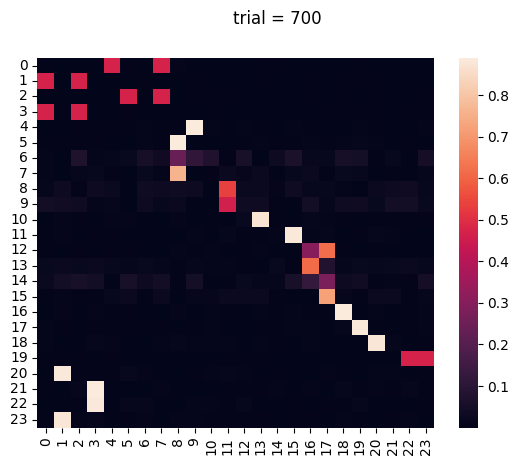

 73%|███████▎  | 798/1099 [00:55<00:20, 14.87it/s]

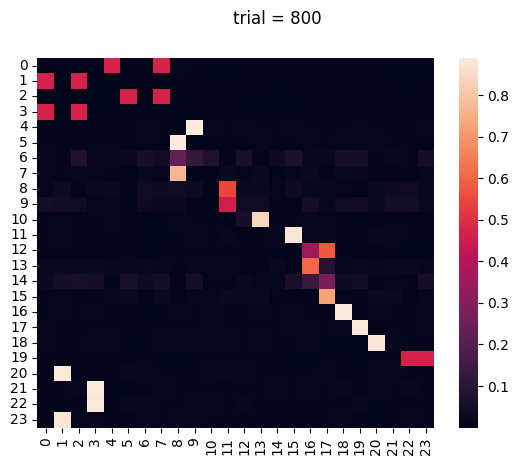

 82%|████████▏ | 898/1099 [01:02<00:13, 14.88it/s]

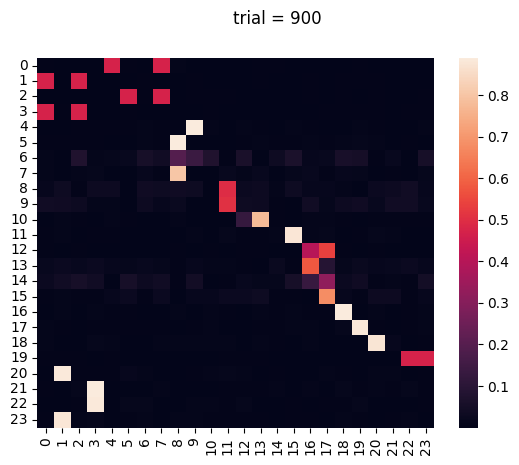

 91%|█████████ | 998/1099 [01:09<00:06, 14.89it/s]

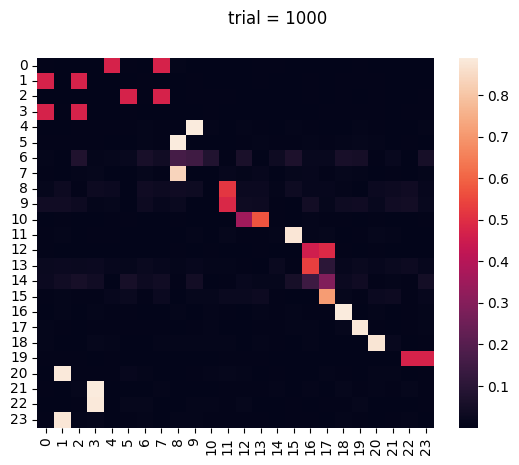

100%|██████████| 1099/1099 [01:16<00:00, 14.30it/s]


' TO DO - check out the inference dynamics that look awfully weird, maybe play with the clips there too '

In [ ]:


'''
Ongoing 
'''


## Learning loop

#Set up learning loop - question : times ? or no times ? How do I decide for the gradient ? Do I just do one step?? TBD 
import matplotlib.pyplot as plt
'''
E step with a loop, check the time reaquired for convergence
M Step is a 1 time step thing for Transition matrix update
/ ! \ Need to store previous values of the softmax hidden state parametrization for this to work out

To test : 
    - Look into latent state resetting to make sure it is doing what I want it to do
    - What did I really change in the inference to let it converge ?
'''

##  Log likelihood -- Gives the negative free energy associated with a given observation x(t) in theory. need to store their evolution separately in theory -here doesnt work yet as goes over 1 

def L(Hnow,Hprev,cA,cur_clones,pre_clone): 
    return np.sum(  (Hnow[cur_clones])*(np.log(np.linalg.matmul(cA[cur_clones,pre_clone],Hprev[pre_clone])) - np.log(Hnow[cur_clones]))   )



## Learning parameters

# Learning parameters - 2 time scales
It = 20 # Inference time scale for E step "network balance" 
dtau = 0.01 # Inference learning rate
Lrate = 1 # Learning rate for M-step
Time = np.arange(1,len(seq)-1) #Explicit time = sequence length
# q = 0.95
# clip_pos = np.abs(np.quantile(a,q)) # clipping range of the gradient on cA update
# clip_neg = np.quantile(a,1-q)
clip_pos = 3 
clip_neg = -6


# Gradient noise - avoid saddles
eps = 1e-5 

# Initialize learning metrics
Inf_params = [np.zeros(shape=(2,1))]
LogL = [] #log likelihood of the model - actually this is the Free energy

test_energy = [] # Need to update for the whole sequence each time


for t in tqdm(Time):
    
    # Give slices of clone coords
    current_clones = decoder(seq[t])
    previous_clones = decoder(seq[t-1]) 
    
    ## Prepare for loop on E step - Inference step
    
    balance_time = 0    
    Transition = cA[current_clones,previous_clones] # Fetch the current clones that correspond 

    # Inf_h = [h[current_clones][np.newaxis].T] 
    Inf_h = []
    Inf_params = []
    Hprev = h.copy()
    
    
    ###### inference parameter reset -- testting POWER LAW
    
    # Initialize latent states - random 
    h_params = rd.rand(latent_labels.shape[0])
    h = np.zeros(shape=latent_labels.shape)#soft max in slices
    for clone in range(len(n_clones)):
        clone_slice = slice(state_loc[clone],state_loc[clone]+n_clones[clone])
        h[clone_slice] = sc.special.softmax(h_params[clone_slice]) 


    # Latent initialization with power law
    # ''' Tests ongoing '''
    # power = 0.5
    # C = 1 #arbitrary constant - gives scale of parameter space
    # h = np.ones(shape=latent_labels.shape)
    # h[4:] = rd.power(power,size=(h[4:].shape))
    # h_params = np.zeros(shape=latent_labels.shape)
    # for clone in range(len(n_clones)):
    #     clone_slice = slice(state_loc[clone],state_loc[clone]+n_clones[clone])
        
    #     h[clone_slice] /= np.sum(h[clone_slice])
        
    #     h_params[clone_slice] = np.log(h[clone_slice]) + C 
    
    

    
    while balance_time < It: # Loop over E step for ssame presentation of stim
        
        balance_time += dtau
        
        #Subset hidden states to get prior estimate, and past estimate
        Qnow = h[current_clones]
        Qprev = Hprev[previous_clones] ################ New

        
        #Compute inference gradient and update state space parametization in clones that are concerned (subsetNow)
        grad_h = dtau*dh(Qnow,Qprev,Transition)  #with noise
        grad_h_noisy = grad_h + rd.rand(*grad_h.shape)*eps
        
        # Inf_params.append(Inf_params[-1] + grad_h.reshape(h_params.loc[:,subsetNow].shape).flatten())
        # print(f'dh is {dh(Qnow,Qprev,Transition)}')
              

        
        #Update state space according to inference step (gradient update)
        h_params[current_clones] += grad_h_noisy
        h[current_clones] = sc.special.softmax(h_params[current_clones]) #Update h after having updated the parameters
        
        
        if h_params[current_clones].shape == (1,): 
            Inf_h.append(np.ones((2,1))*42)
            # Inf_params.append(Inf_params[-1] + grad_h[np.newaxis].T)
            Inf_params.append(np.ones((2,1))*42)
            continue
        else : 
            k = h[current_clones][np.newaxis].T.copy() #necessay otherwise values are sotred and updated lol
            Inf_h.append(k) #WHAT BREAKS HERE ???
            # Inf_params.append(Inf_params[-1] + grad_h[np.newaxis].T)
            Inf_params.append(grad_h[np.newaxis].T)
    
    
    ##### Check convergence -- plots:\
    # Inf_params = np.concatenate(Inf_params,axis=1)
    # Inf_h = np.concatenate(Inf_h,axis=1)
    
    # Convergence_Params = Inf_params[0]   
    # Convergence = Inf_h[0]
    # Conv_X = np.arange(0,Convergence.shape[0])
    
    # fig,ax = plt.subplots(ncols=2,nrows=1)
    # ax[0].plot(Conv_X,Convergence,label='Latent state')
    # ax[0].set_ylim((0,1))
    # ax[1].plot(Conv_X,Convergence_Params,label='Parameter state')
    
    # fig.suptitle(f'x(t) = {seq[t]}')
    # fig.tight_layout()
    # plt.show()
    
   
    ''' Learn Transition matrix '''
    
    ############################ Alternative with 1 time step


    #Subset hidden states to get prior estimate, and past estimate
    Qnow = h[current_clones]
    Qprev = h[previous_clones]


    Transition = cA[current_clones,previous_clones]
    
    grad_a = da(Qnow,Qprev,Transition) ############################################### 
    grad_a_noisy = grad_a + np.random.rand(*grad_a.shape)*eps

    a[current_clones,previous_clones] = np.clip(a[current_clones,previous_clones] + Lrate*grad_a_noisy, clip_neg,clip_pos ) 
    
    #Update transition matrix w/ new parameters : 
    cA[:,previous_clones] = sc.special.softmax(a[:,previous_clones],axis=0) 


    ''' Learn with a loop (short) '''
    ############################ Alternative with a loop - seems to be good for the model? 
    
    # ITt = 0.5 ############################ Could defo shorten this 
    # balance_time = 0
    
    # #Subset hidden states to get prior estimate, and past estimate
    # Qnow = h[current_clones]
    # Qprev = h[previous_clones]
    
    # while balance_time < ITt: # Loop over E step for ssame presentation of stim
       
    #     balance_time += Lrate

    #     Transition = cA[current_clones,previous_clones]
        
    #     grad_a = da(Qnow,Qprev,Transition) 
    #     grad_a_noisy = grad_a + np.random.rand(*grad_a.shape)*eps
        
    #     a[current_clones,previous_clones] = np.clip(a[current_clones,previous_clones] + Lrate*grad_a_noisy,-5,5 ) 
        
        
    #     #Update transition matrix w/ new parameters : 
    #     cA[:,previous_clones] = sc.special.softmax(a[:,previous_clones],axis=0) 



    ''' Compute log-likelihood ELBO on the current observable seq[t] and store it '''
    LogL.append(L(h,Hprev,cA,cur_clones = current_clones, pre_clone = previous_clones))

        
    ''' Plot matrix over time '''
    if t%100 == 0:
        title = f'trial = {t}'
        fig, ax = plt.subplots()
        sns.heatmap(cA.T,ax=ax)
        fig.suptitle(title)
        plt.show()    


#### Side by side transition matrices

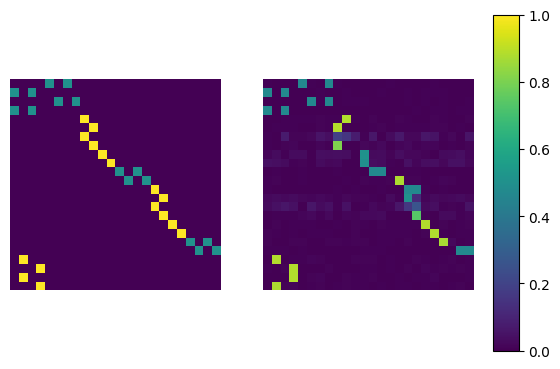

In [69]:
## Plot Transition matrix learning            

'''
Plot 2 transition matrices side by side for result

Current notes : Where the model is supposed to give weight, it actually takes it away. Real transitions are becoming less likely. Local minimum or equation is shit? 

'''
import matplotlib.pyplot as plt
fig, ax = plt.subplots(nrows=1,ncols=2)
sns.heatmap(A.T,cmap='viridis',vmin=0,vmax=1,ax=ax[0], cbar=False,square=True,annot=False,fmt='.1f',xticklabels=False, yticklabels=False)
matCB = sns.heatmap(cA.T,cmap='viridis',vmin=0,vmax=1,ax=ax[1], cbar=False,square=True,annot=False,fmt='.1f',xticklabels=False, yticklabels=False)
# matCB = ax[1].matshow(cA,cmap='viridis',vmin=0,vmax=1)

# add space for colour bar
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.04, 0.7])
fig.colorbar(matCB.get_children()[0], cax=cbar_ax)




<Axes: >

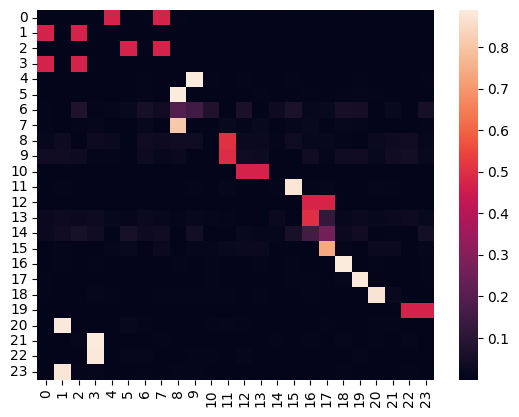

In [70]:
sns.heatmap(cA.T)

In [71]:
position = 0
seq2 = [np.int64(0)]

for t in tqdm(range(T)):
    position = rd.choice(a = POS, p = cA[:,position]) #Update position according to transition matrix
    seq2.append(encoder(position)) #Append decoded sequence
    

100%|██████████| 1100/1100 [00:00<00:00, 28725.61it/s]


#### Plot LogL of the model

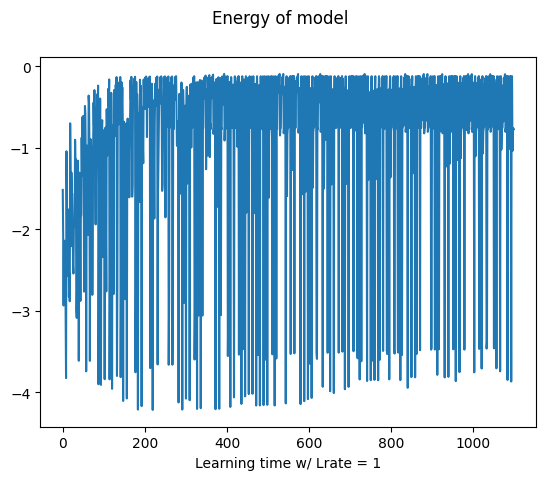

' Should be the evidence lower bound of the model of log (p(x)). Meaning this is the *negative variational energy. should be negative and progressively converge to value of p(x) between 0 and 1 \npositive values should be regarded as something not functioning correctly or a math error \n'

In [72]:
## Plot log likelihood of the model -- not fixed yet 

# %matplotlib widget
import matplotlib.pyplot as plt
plt.close()
plt.plot(np.arange(0,Time[-1],step=1),LogL)
plt.suptitle('Energy of model')
plt.xlabel(f'Learning time w/ Lrate = {Lrate}')
plt.show()

''' Should be the evidence lower bound of the model of log (p(x)). Meaning this is the *negative variational energy. should be negative and progressively converge to value of p(x) between 0 and 1 
positive values should be regarded as something not functioning correctly or a math error 
'''